In [12]:
# IMPORT LIBRARIES
import pandas as pd
import plotly.express as px

In [2]:
# LOAD DATASET
df = pd.read_excel("Cleaned_Dataset.xlsx")

In [4]:
# Preview Dataset
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [5]:
# Dataset Shape
print("Rows, Columns:", df.shape)

Rows, Columns: (1200, 14)


In [ ]:
# DATA VISUALIZATION & INSIGHTS

# Revenue by Product (Bar Chart)
revenue = df.groupby("Product")["TotalPrice"].sum().reset_index()

fig = px.bar(
    revenue,
    x="Product",
    y="TotalPrice",
    title="Revenue by Product"
)

fig.show()

In [ ]:
# Revenue by Product Insights
top_product = revenue["TotalPrice"].idxmax()
top_revenue = revenue["TotalPrice"].max()

print("\n===== INSIGHT =====")
print(f"{top_product} is the highest revenue-generating product.")
print(f"Revenue Generated: {top_revenue:.2f}")


===== INSIGHT =====
0 is the highest revenue-generating product.
Revenue Generated: 195620.11


In [21]:
# Sales Trend (Line Chart)

sales_trend = df.groupby("Date")["TotalPrice"].sum().reset_index()

fig = px.line(
    sales_trend,
    x="Date",
    y="TotalPrice",
    title="Sales Trend Over Time"
)

fig.show()

In [ ]:
# 2. Sales Trend Over Time (Line Chart)
peak_date = sales_trend["TotalPrice"].idxmax()
peak_sales = sales_trend["TotalPrice"].max()

print("\n===== INSIGHT =====")
print(f"Highest sales were recorded on {peak_date}.")
print(f"Peak Revenue: {peak_sales:.2f}")
print("This period represents the strongest sales performance and may indicate seasonal demand or successful business activities.")


===== INSIGHT =====
Highest sales were recorded on 172.
Peak Revenue: 9290.49
This period represents the strongest sales performance and may indicate seasonal demand or successful business activities.


In [22]:
#Payment Method Distribution (Pie Chart)
payment = df["PaymentMethod"].value_counts().reset_index()
payment.columns = ["PaymentMethod", "Count"]

fig = px.pie(
    payment,
    names="PaymentMethod",
    values="Count",
    title="Payment Method Distribution"
)

fig.show()

In [28]:
# Payment Method Distribution (Pie Chart)
top_payment = payment.idxmax()
top_count = payment.max()

print("\n===== INSIGHT =====")
print(f"{top_payment} is the most preferred payment method.")
print(f"Number of Transactions: {top_count}")
print("Customers show a clear preference for this payment option, highlighting its importance in the purchasing process.")


===== INSIGHT =====
PaymentMethod    0
Count            0
dtype: int64 is the most preferred payment method.
Number of Transactions: PaymentMethod    Online
Count               258
dtype: object
Customers show a clear preference for this payment option, highlighting its importance in the purchasing process.


In [23]:
# Order Value Distribution (Histogram)
fig = px.histogram(
    df,
    x="TotalPrice",
    nbins=20,
    title="Order Value Distribution"
)

fig.show()

In [30]:
# Order Value Distribution (Histogram)
avg_order = df["TotalPrice"].mean()

print("\n===== INSIGHT =====")
print(f"Average Order Value: {avg_order:.2f}")
print("Most orders are concentrated around the average value, while a few high-value transactions contribute significantly to total revenue.")


===== INSIGHT =====
Average Order Value: 1053.97
Most orders are concentrated around the average value, while a few high-value transactions contribute significantly to total revenue.


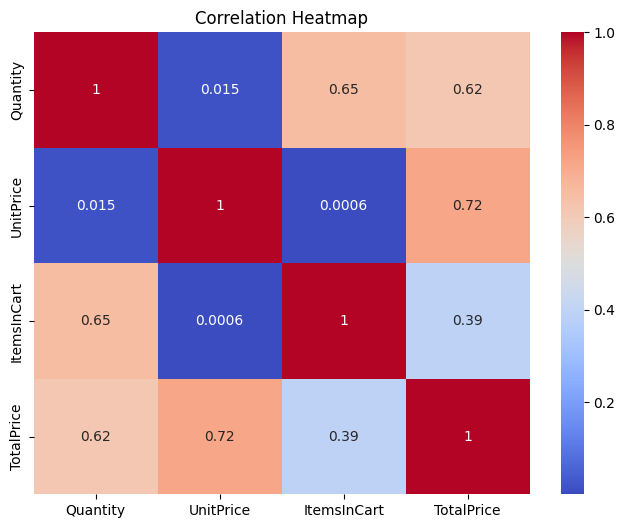

In [24]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation Heatmap 
corr_matrix = df[numeric_cols].corr()

print("\n===== INSIGHT =====")
print("The heatmap reveals relationships between numerical variables.")
print("Higher correlation values indicate stronger relationships, while values close to zero indicate weak relationships.")
print("This helps identify factors that may influence business performance.")


===== INSIGHT =====
The heatmap reveals relationships between numerical variables.
Higher correlation values indicate stronger relationships, while values close to zero indicate weak relationships.
This helps identify factors that may influence business performance.


In [34]:
# project conclusion
print("\n===== CONCLUSION =====")
print("The visualizations revealed key insights into product performance, sales trends, customer payment preferences, order value distribution, and relationships among numerical variables.")
print("These findings can support data-driven decision-making and improve overall business strategy.")


===== CONCLUSION =====
The visualizations revealed key insights into product performance, sales trends, customer payment preferences, order value distribution, and relationships among numerical variables.
These findings can support data-driven decision-making and improve overall business strategy.
